In [1]:
# Import required libraries for dataset handling and data manipulation
from datasets import load_dataset_builder , load_dataset
import pandas as pd
import matplotlib.pyplot as plt


# Load the dataset builder to inspect metadata without downloading the full dataset
ds_builder = load_dataset_builder("GBaker/MedQA-USMLE-4-options")

In [2]:
ds_builder.info.features

{'question': Value('string'),
 'answer': Value('string'),
 'options': {'A': Value('string'),
  'B': Value('string'),
  'C': Value('string'),
  'D': Value('string')},
 'meta_info': Value('string'),
 'answer_idx': Value('string'),
 'metamap_phrases': List(Value('string'))}

In [3]:
ds = load_dataset("GBaker/MedQA-USMLE-4-options")

In [4]:
ds['train'][0]

{'question': 'A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?',
 'answer': 'Nitrofurantoin',
 'options': {'A': 'Ampicillin',
  'B': 'Ceftriaxone',
  'C': 'Doxycycline',
  'D': 'Nitrofurantoin'},
 'meta_info': 'step2&3',
 'answer_idx': 'D',
 'metamap_phrases': ['23 year old pregnant woman',
  'weeks presents',
  'burning',
  'urination',
  'states',
  'started 1 day',
  'worsening',
  'drinking',
  'water',
  'taking cranberry extract',
  'feels well',
  'follo

In [5]:
df = ds['train'].to_pandas()

In [6]:
df.head(10)

,question,answer,options,meta_info,answer_idx,metamap_phrases
0,A 23-year-old pregnant woman at 22 weeks gesta...,Nitrofurantoin,"{'A': 'Ampicillin', 'B': 'Ceftriaxone', 'C': '...",step2&3,D,"[23 year old pregnant woman, weeks presents, b..."
1,A 3-month-old baby died suddenly at night whil...,Placing the infant in a supine position on a f...,{'A': 'Placing the infant in a supine position...,step2&3,A,"[3 month old baby died, night, asleep, mother,..."
2,A mother brings her 3-week-old infant to the p...,Abnormal migration of ventral pancreatic bud,{'A': 'Abnormal migration of ventral pancreati...,step1,A,"[mother, week old infant, pediatrician's offic..."
3,A pulmonary autopsy specimen from a 58-year-ol...,Thromboembolism,"{'A': 'Thromboembolism', 'B': 'Pulmonary ische...",step1,A,"[pulmonary autopsy specimen, 58 year old woman..."
4,A 20-year-old woman presents with menorrhagia ...,Von Willebrand disease,"{'A': 'Hemophilia A', 'B': 'Lupus anticoagulan...",step1,D,"[20 year old woman presents, menorrhagia, past..."
5,A 40-year-old zookeeper presents to the emerge...,Scorpion sting,"{'A': 'Aspirin', 'B': 'Oral contraceptive pill...",step1,C,"[40 year old, presents, emergency department, ..."
6,A 25-year-old primigravida presents to her phy...,24-hour urine protein,"{'A': 'Bilirubin assessment', 'B': 'Coagulatio...",step2&3,D,"[year old primigravida presents, physician, ro..."
7,A 3900-g (8.6-lb) male infant is delivered at ...,Gastric fundus in the thorax,"{'A': 'Gastric fundus in the thorax', 'B': 'Pa...",step1,A,"[male infant, delivered, weeks, gestation, spo..."
8,A 62-year-old woman presents for a regular che...,Digoxin,"{'A': 'Atenolol', 'B': 'Diltiazem', 'C': 'Prop...",step1,D,"[62 year old woman presents, regular check-up,..."
9,A 35-year-old male presents to his primary car...,Persistent congestion,"{'A': 'Epistaxis', 'B': 'Permanent loss of sme...",step1,D,"[35 year old male presents, primary care physi..."


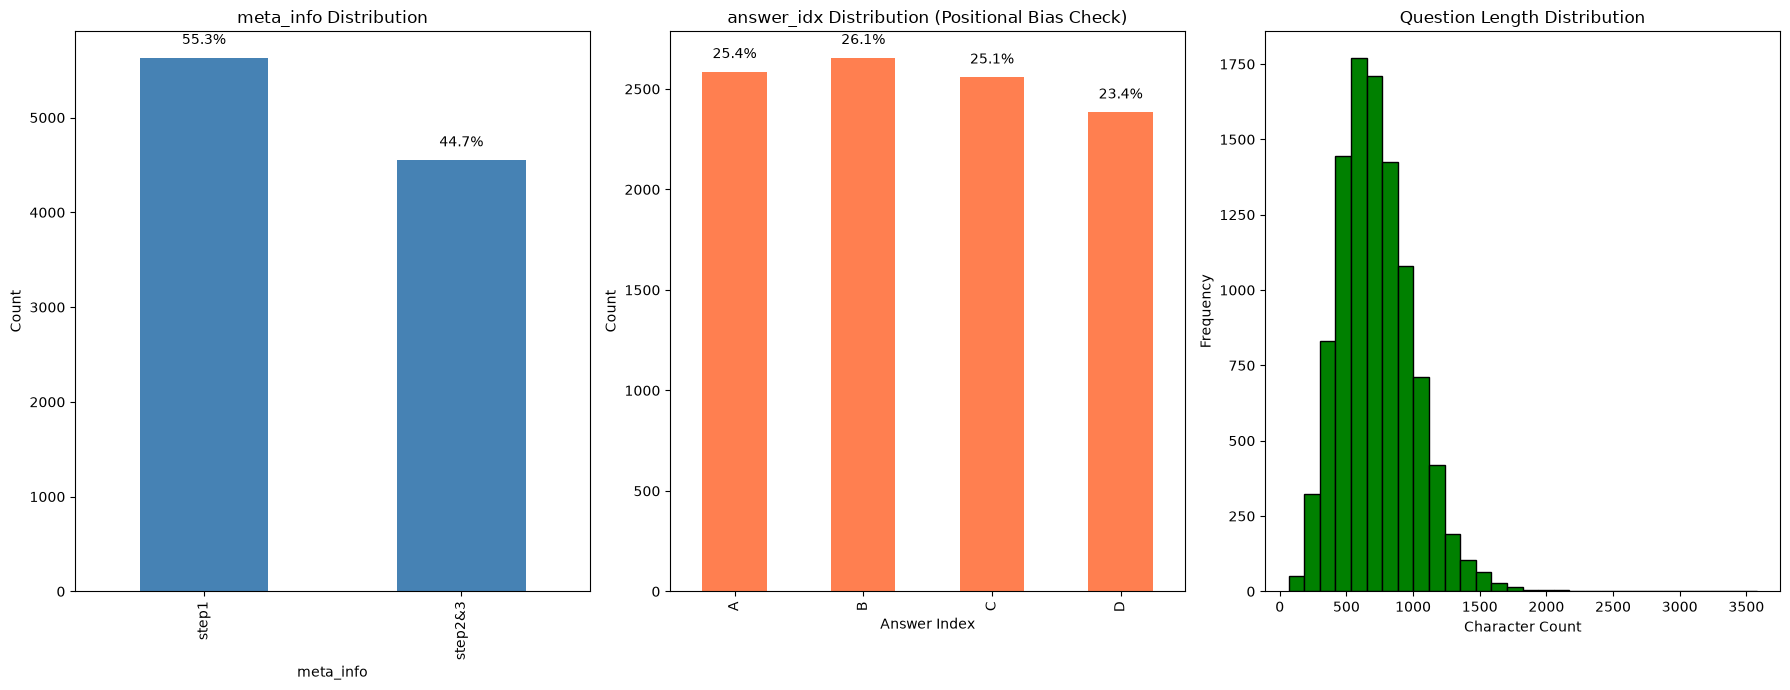

Average question length: 724 characters
Min question length: 66 characters
Max question length: 3577 characters


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# 1. meta_info distribution
meta_counts = df['meta_info'].value_counts()
meta_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('meta_info Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('meta_info')

for i, count in enumerate(meta_counts):
    pct = count / meta_counts.sum() * 100
    axes[0].text(i, count + 0.02 * meta_counts.max(), f'{pct:.1f}%', ha='center', va='bottom')

# 2. answer_idx distribution
answer_counts = df['answer_idx'].value_counts().sort_index()
answer_counts.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('answer_idx Distribution (Positional Bias Check)')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Answer Index')

for i, count in enumerate(answer_counts):
    pct = count / answer_counts.sum() * 100
    axes[1].text(i, count + 0.02 * answer_counts.max(), f'{pct:.1f}%', ha='center', va='bottom')

# 3. Question length distribution
df['question_length'] = df['question'].str.len()
axes[2].hist(df['question_length'], bins=30, color='green', edgecolor='black')
axes[2].set_title('Question Length Distribution')
axes[2].set_ylabel('Frequency')
axes[2].set_xlabel('Character Count')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Average question length: {df['question_length'].mean():.0f} characters")
print(f"Min question length: {df['question_length'].min()} characters")
print(f"Max question length: {df['question_length'].max()} characters")